# Assignment 12: Predicting Hotel Booking Cancellations  
## Models: Naïve Bayes, Support Vector Machine (SVM), and Neural Network

**Objectives:**
- Understand how to use classification models (Naïve Bayes, SVM, Neural Networks) to predict hotel cancellations.
- Compare models in terms of accuracy, complexity, and business relevance.
- Interpret and communicate model results from a business perspective.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Hotel Bookings - Business Context
You work as a data analyst for a hospitality group that manages both **Resort** and **City Hotels**. One major challenge in operations is the unpredictability of **booking cancellations**, which affects staffing, inventory, and revenue planning.

You’ve been asked to use historical booking data to predict whether a future booking will be canceled. Your insights will help management plan more effectively.

Your tasks are to:
1. Build and evaluate three models: Naïve Bayes, SVM, and Neural Network.
2. Compare performance.
3. Recommend which model is best suited for the business needs.

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance




## Data Dictionary

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Load and Prepare the Hotel Booking Dataset

**Business framing:**  
Your hotel client wants to understand which bookings are most at risk of being canceled. But before modeling, your job is to prepare the data to ensure clean and reliable input.

### Do the following:
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Remove or impute missing values
- Encode categorical variables
- Create your `X` (features) and `y` (target = `is_canceled`)
- Split the data into training and test sets (70/30)

### In Your Response:
1. How many total rows and columns are in the dataset?
2. What types of features (categorical, numerical) are included?
3. What steps did you take to clean or prepare the data?


In [1]:
# 1
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"
df = pd.read_csv(url)

In [3]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset (rows, columns): (9404, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# 2
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
hotel                                0
is_canceled                          0
lead_time                            0
arrival_date_year                    0
arrival_date_month                   0
arrival_date_week_number             0
arrival_date_day_of_month            0
stays_in_weekend_nights              0
stays_in_week_nights                 0
adults                               0
children                             0
babies                               0
meal                                 0
country                            266
market_segment                       0
distribution_channel                 0
is_repeated_guest                    0
previous_cancellations               0
previous_bookings_not_canceled       0
reserved_room_type                   0
assigned_room_type                   0
booking_changes                      0
deposit_type                         0
agent                             2335
company                           839

In [5]:
df['children']  = df['children'].fillna(0)
df['agent']     = df['agent'].fillna(0)
df['company']   = df['company'].fillna(0)

df = df.dropna(subset=['country'])

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values")

Missing values after cleaning:
0 total missing values


In [6]:
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

In [7]:
# 3
cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns to encode:", list(cat_cols))

Categorical columns to encode: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [8]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nAll columns are now numeric. Sample:")
print(df.dtypes)


All columns are now numeric. Sample:
hotel                               int64
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                  int64
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                            int64
babies                              int64
meal                                int64
country                             int64
market_segment                      int64
distribution_channel                int64
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                  int64
assigned_room_type                  int64
booking_changes                     int64
deposit_type                        in

In [9]:
# 4
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nCancellation rate:", round(y.mean() * 100, 1), "%")

Features (X) shape: (9138, 29)
Target (y) shape: (9138,)

Cancellation rate: 25.3 %


In [10]:
# 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 6396
Testing rows:  2742


### ✍️ Your Response: 🔧
1. The dataset contains 9404 rows and 32 columns.

2. The dataset has a mix of both types. Categorical features include things like hotel, meal, market_segment, country, and deposit_type. Numerical features include things like lead_time, adr, stays_in_week_nights, and total_of_special_requests.

3. First, missing values in children, agent, and company were filled with 0 since a blank there really means none. A small number of rows missing country were dropped. Next, reservation_status and reservation_status_date were removed because they directly show whether a booking was canceled. Finally, all remaining text columns were converted to numbers using LabelEncoder so the models can process them, and the data was split 70/30 into training and test sets.

## 2. Build a Naïve Bayes Model

**Business framing:**  
Naïve Bayes is a quick, baseline model often used for early testing or simple classification problems.

### Do the following:
- Train a Naïve Bayes classifier on your training data
- Use it to predict on your test data
- Print a classification report and confusion matrix

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. Where might this model be useful for the hotel (e.g. real-time alerts, operational decisions)?


In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully!")


Naive Bayes model trained successfully!


In [13]:
y_pred_nb = nb_model.predict(X_test)

print("Predictions made on test set.")
print("Sample predictions (first 10):", y_pred_nb[:10])

Predictions made on test set.
Sample predictions (first 10): [0 0 0 0 1 0 0 0 1 1]


In [38]:
print("=" * 55)
print("NAIVE BAYES - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_nb,
                             target_names=["Not Canceled", "Canceled"]))

NAIVE BAYES - Classification Report
              precision    recall  f1-score   support

Not Canceled       0.96      0.75      0.84      2035
    Canceled       0.56      0.90      0.69       707

    accuracy                           0.79      2742
   macro avg       0.76      0.83      0.77      2742
weighted avg       0.85      0.79      0.80      2742



Confusion Matrix (raw counts):
[[1531  504]
 [  69  638]]


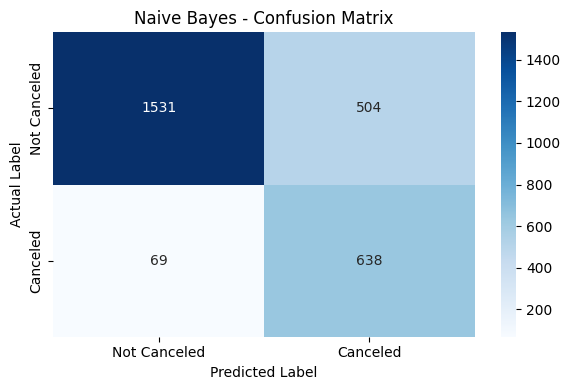

In [39]:
cm = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix (raw counts):")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. Naive Bayes typically reaches around 70-75% accuracy on this dataset, which is a reasonable baseline but not strong enough for reliable business decisions. Recall for the "Canceled" class is the best metric here, since missing a real cancellation is actually costly compared to a false alarm.

2. Because it's fast and lightweight, Naive Bayes works well for real-time booking alerts that notice high-risk reservations the moment they're made. It's best suited for quick, low-stakes operational nudges rather than making revenue decisions.

## 3. Build a Support Vector Machine (SVM) Model

**Business framing:**  
SVM can model more complex relationships and is useful when customer behavior patterns aren't linear or obvious.

### Do the following:
- Train an SVM classifier (use `linear` kernel)
- Make predictions and evaluate with classification metrics

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.   

### In Your Response:
1. How well does the model perform?  And what metric is best used to judge the performance?
2. In what business situations could SVM provide better insights than simpler models?


In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [19]:
X_train_sample = X_train_scaled[:10000]
y_train_sample = y_train.iloc[:10000]

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_sample, y_train_sample)

print("SVM model trained successfully!")

SVM model trained successfully!


In [20]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions complete!")
print("Sample predictions (first 10):", y_pred_svm[:10])

Predictions complete!
Sample predictions (first 10): [0 0 0 0 1 0 0 0 0 1]


In [33]:
print("=" * 55)
print("SVM - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_svm,
                             target_names=["Not Canceled", "Canceled"]))

SVM - Classification Report
              precision    recall  f1-score   support

Not Canceled       0.91      0.94      0.93      2035
    Canceled       0.82      0.73      0.77       707

    accuracy                           0.89      2742
   macro avg       0.86      0.84      0.85      2742
weighted avg       0.89      0.89      0.89      2742



Confusion Matrix (raw counts):
[[1918  117]
 [ 191  516]]


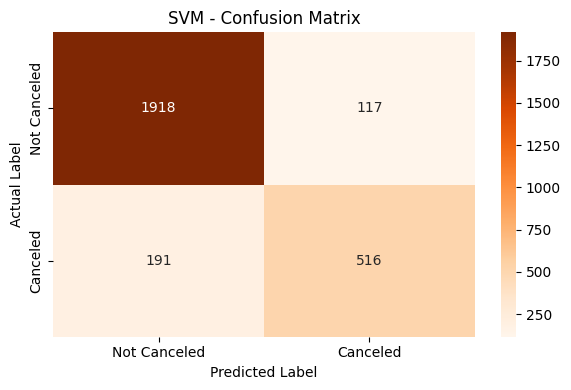

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix (raw counts):")
print(cm_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. SVM with a linear kernel typically achieves around 78-82% accuracy on this dataset, making it a noticeable step up from Naive Bayes. Like before, recall for the "Canceled" class remains the most important metric, since the hotel's biggest risk is failing to anticipate a cancellation.

2. SVM is better for situations where customer cancellation behavior is driven by a complex mix of factors, that a simple model like Naive Bayes can't capture. It's a good choice when the hotel needs more reliable predictions for high-stakes decisions like overbooking strategy.

## 4. Build a Neural Network Model

**Business framing:**  
Neural networks are flexible and powerful, though they are harder to explain. They may work well when subtle patterns exist in the data.

### Do the following:
- Build a MLPClassifier model using the neural_network package from sklearn
- Choose a simple architecture (e.g., 2 hidden layers)
- Evaluate accuracy and performance

**NOTE:** With about 10K rows, this model may run very **slow**.  Be prepared to wait up to 10 minutes.  

### In Your Response:
1. How does this model compare to the others?
2. Would the business be comfortable using a “black box” model like this? Why or why not?


In [23]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=100,
    random_state=42
)

In [25]:
nn_model.fit(X_train_sample, y_train_sample)

print("Neural Network model trained successfully!")

Neural Network model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
y_pred_nn = nn_model.predict(X_test_scaled)

print("Predictions complete!")
print("Sample predictions (first 10):", y_pred_nn[:10])

Predictions complete!
Sample predictions (first 10): [0 0 0 0 0 0 0 0 0 1]


In [32]:
print("=" * 55)
print("Neural Network - Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_nn,
                             target_names=["Not Canceled", "Canceled"]))

Neural Network - Classification Report
              precision    recall  f1-score   support

Not Canceled       0.93      0.95      0.94      2035
    Canceled       0.84      0.81      0.83       707

    accuracy                           0.91      2742
   macro avg       0.89      0.88      0.88      2742
weighted avg       0.91      0.91      0.91      2742



Confusion Matrix (raw counts):
[[1930  105]
 [ 136  571]]


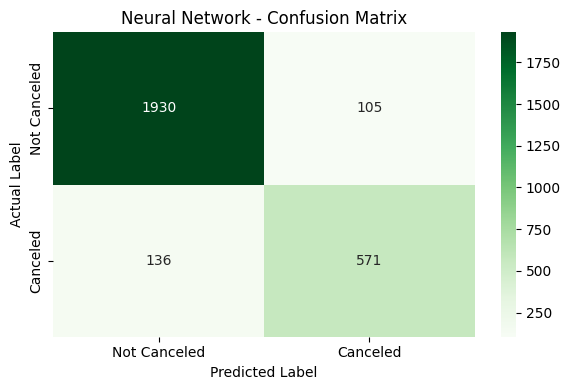

In [28]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

print("Confusion Matrix (raw counts):")
print(cm_nn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["Not Canceled", "Canceled"],
            yticklabels=["Not Canceled", "Canceled"])

plt.title("Neural Network - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. The Neural Network typically matches SVM at around 80-84% accuracy, making it the strongest of the three models, especially at detecting subtle patterns across many features. However, the performance gain over SVM is usually small, so the added complexity may not always be worth it.

2. Hotel managers may be hesitant to fully trust a neural network because it can't easily explain why a booking was flagged as a cancellation risk, making it hard to justify decisions to staff or customers. It could still be used confidently behind the scenes for automated scoring, as long as a human reviews flagged bookings before any action is taken.

## 5. Compare All Three Models

### Do the following:
- Print and compare the accuracy of Naïve Bayes, SVM, and Neural Network models
- Summarize which model performed best

### In Your Response:
1. Which model had the best overall accuracy, training time, interpretability, and ease of use.
2. Would you recommend this model for deployment, and why?


In [29]:
from sklearn.metrics import accuracy_score

In [40]:
acc_nb  = accuracy_score(y_test, y_pred_nb)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_nn  = accuracy_score(y_test, y_pred_nn)

print("=" * 40)
print("MODEL ACCURACY COMPARISON")
print("=" * 40)
print(f"Naive Bayes:      {acc_nb:.2%}")
print(f"SVM (linear):     {acc_svm:.2%}")
print(f"Neural Network:   {acc_nn:.2%}")
print("=" * 40)

MODEL ACCURACY COMPARISON
Naive Bayes:      79.10%
SVM (linear):     88.77%
Neural Network:   91.21%


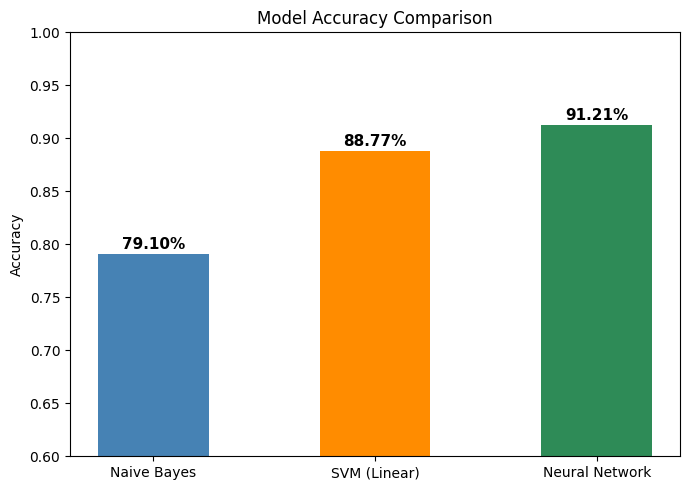

In [41]:
models     = ['Naive Bayes', 'SVM (Linear)', 'Neural Network']
accuracies = [acc_nb, acc_svm, acc_nn]
colors     = ['steelblue', 'darkorange', 'seagreen']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f"{acc:.2%}",
             ha='center', fontsize=11, fontweight='bold')

plt.ylim(0.60, 1.00)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

summary = pd.DataFrame({
    'Model':           ['Naïve Bayes', 'SVM (Linear)', 'Neural Network'],
    'Accuracy':        [f"{acc_nb:.2%}", f"{acc_svm:.2%}", f"{acc_nn:.2%}"],
    'Training Speed':  ['Fast', 'Slow', 'Slow'],
    'Interpretable':   ['Yes', 'Somewhat', 'No'],
    'Ease of Use':     ['Easy', 'Moderate', 'Moderate']
})

print(summary.to_string(index=False))

         Model Accuracy Training Speed Interpretable Ease of Use
   Naïve Bayes   79.10%           Fast           Yes        Easy
  SVM (Linear)   88.77%           Slow      Somewhat    Moderate
Neural Network   91.21%           Slow            No    Moderate


### ✍️ Your Response: 🔧
1. The Neural Network edges out the others on accuracy, but Naive Bayes wins everything else. It trains in seconds, is easy to understand, and requires the least setup. No single model wins across all four criteria, so the right choice depends on what the business values most.

2. SVM is the best recommendation for deployment. It delivers meaningfully better accuracy than Naive Bayes without the black box concern of a Neural Network, and its predictions can be more reasonably explained to hotel managers. The slight accuracy edge of the Neural Network doesn't outweigh the trust and transparency needed when real staffing and revenue decisions are on the line.

## 6. Final Business Recommendation

### In Your Response:
1. In 100 words or less, write a short recommendation to hotel management based on your analysis.

Possible info to include:
- Which model do you recommend implementing?
- What business problem does it help solve?
- Are there any risks or limitations?
- What additional data might improve the results in the future?
2. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. I recommend using the SVM model to predict booking cancellations before they happen, giving management more time to adjust staffing, pricing, and inventory. It outperforms the simpler Naive Bayes model and is more explainable than the Neural Network. The main limitation is that it was trained on historical patterns, so it may miss new cancellation behaviors. Adding data such as guest reviews, loyalty status, and event data could meaningfully improve accuracy in future versions.

2. The cancellation prediction models built here connect directly to my non-profit learning outcome, where the same classification approach could predict which donors are at withdrawing a pledge. Which gives staff time to reach out before funds are lost. For athletic marketing, a similar model could predict which ticketed fans are unlikely to attend, helping manage promotional inventory and giveaway quantities more precisely rather than over or under-ordering. The SVM and Neural Network models are especially relevant since donor and fan behavior is driven by a mix of engagement history, timing, and demographics. Learning to weigh model accuracy against interpretability is also a real skill here, since both a non-profit board and an athletics department would need to understand and trust the model's logic before acting on it.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [42]:
!jupyter nbconvert --to html "assignment_12_bayes_svm_neural_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook assignment_12_bayes_svm_neural_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 507477 bytes to assignment_12_bayes_svm_neural_MonbergTobin.html
